In [3]:
# Cell 1: Imports and Configuration
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure publication-ready plots
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 2,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42
})

# Define datasets and base paths
DATASETS = ["CIFAR10", "POKEMON"] # Update these to match your actual dataset folders
BASE_DIR = os.path.abspath(os.path.join("..", "results", "tests"))

In [4]:
# Cell 2: Robust Data Loading
import os
import glob
import pandas as pd

# 1. Dynamically find the root folder (assuming notebook is in root/notebooks)
current_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(current_dir, ".."))

# 2. Define the path to the 'tests' directory
tests_dir = os.path.join(root_dir, "results", "tests")
print(f"Searching for data in: {tests_dir}\n")

global_results = []
layer_results = []

# 3. Search for all quantization_results CSVs recursively (looks inside 'runs' automatically)
global_pattern = os.path.join(tests_dir, "**", "quantization_results_*.csv")
global_files = glob.glob(global_pattern, recursive=True)

if not global_files:
    print(f"WARNING: No global result files found using pattern: {global_pattern}")
else:
    for file in global_files:
        df = pd.read_csv(file)
        
        # Extract dataset name from the file name (e.g., quantization_results_CIFAR10.csv -> CIFAR10)
        filename = os.path.basename(file)
        dataset = filename.replace("quantization_results_", "").replace(".csv", "").replace("_", "")
        df["dataset"] = dataset
        global_results.append(df)
        print(f"Loaded global file: {filename} (Assigned Dataset: {dataset})")

# 4. Search for all fidelity AVG CSVs recursively
fidelity_pattern = os.path.join(tests_dir, "**", "fidelity_*_*_AVG.csv")
fidelity_files = glob.glob(fidelity_pattern, recursive=True)

if not fidelity_files:
    print(f"WARNING: No fidelity files found using pattern: {fidelity_pattern}")
else:
    for file in fidelity_files:
        df = pd.read_csv(file)
        
        # Extract dataset name from the folder structure (.../tests/{dataset}/runs/...)
        path_parts = os.path.normpath(file).split(os.sep)
        try:
            tests_idx = path_parts.index("tests")
            dataset = path_parts[tests_idx + 1]
        except ValueError:
            dataset = "UNKNOWN"
            
        df["dataset"] = dataset
        # Extract experiment name
        exp_name = os.path.basename(file).replace("fidelity_", "").replace("_AVG.csv", "")
        df["config_name"] = exp_name
        layer_results.append(df)
        print(f"Loaded fidelity file: {os.path.basename(file)} (Assigned Dataset: {dataset})")

# 5. Combine into main DataFrames
if global_results:
    df_global = pd.concat(global_results, ignore_index=True)
    print("\n--> Successfully created df_global!")
else:
    print("\n--> FAILED to create df_global. Please check your folder structure.")
    df_global = pd.DataFrame() # Create empty to prevent NameErrors in Cell 3

if layer_results:
    df_layer = pd.concat(layer_results, ignore_index=True)
    print("--> Successfully created df_layer!")
else:
    print("--> FAILED to create df_layer. Please check your folder structure.")
    df_layer = pd.DataFrame()

Searching for data in: /home/dominic/Desktop/Research-Project/Forschungsprojekt/results/tests

Loaded global file: quantization_results_CIFAR10.csv (Assigned Dataset: CIFAR10)
Loaded global file: quantization_results_CIFAR100.csv (Assigned Dataset: CIFAR100)
Loaded global file: quantization_results_FASHION_MNIST.csv (Assigned Dataset: FASHIONMNIST)
Loaded global file: quantization_results_MNIST.csv (Assigned Dataset: MNIST)
Loaded global file: quantization_results_POKEMON.csv (Assigned Dataset: POKEMON)
Loaded fidelity file: fidelity_Affine_PTQ_AVG.csv (Assigned Dataset: CIFAR10)
Loaded fidelity file: fidelity_Symmetric_PTQ_AVG.csv (Assigned Dataset: CIFAR10)
Loaded fidelity file: fidelity_PoT_PTQ_AVG.csv (Assigned Dataset: CIFAR10)
Loaded fidelity file: fidelity_Affine_PTQ_AVG.csv (Assigned Dataset: CIFAR100)
Loaded fidelity file: fidelity_Symmetric_PTQ_AVG.csv (Assigned Dataset: CIFAR100)
Loaded fidelity file: fidelity_PoT_PTQ_AVG.csv (Assigned Dataset: CIFAR100)
Loaded fidelity file

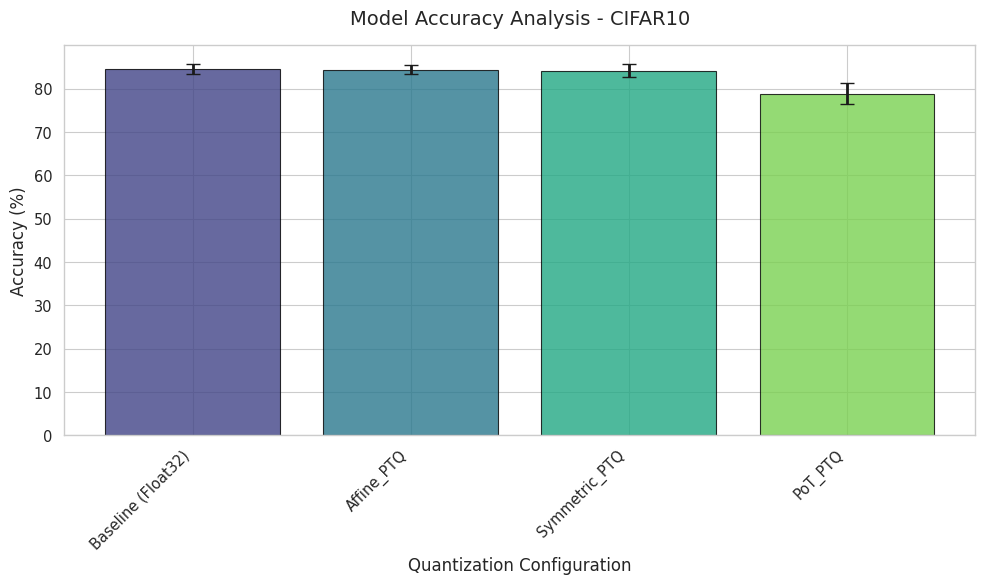

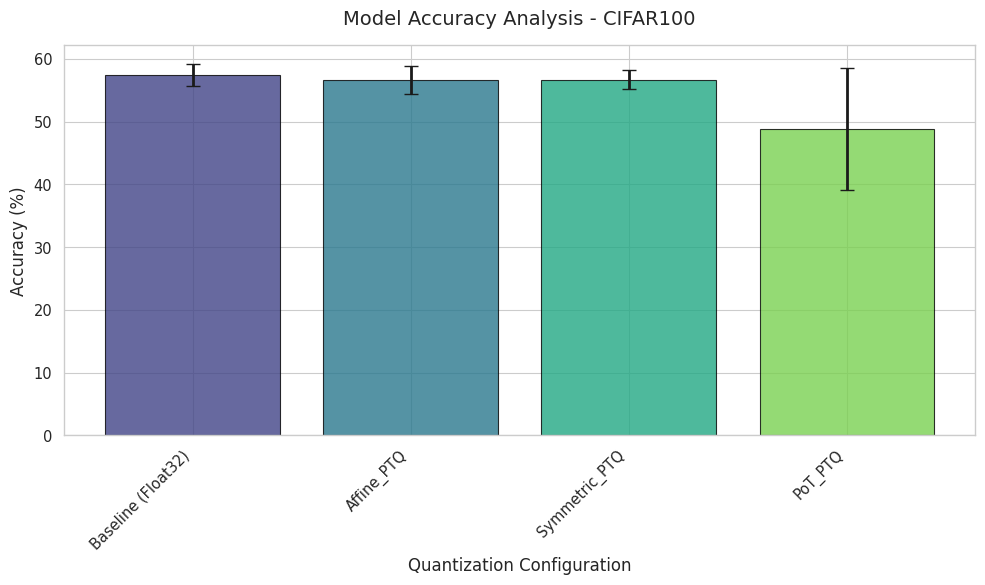

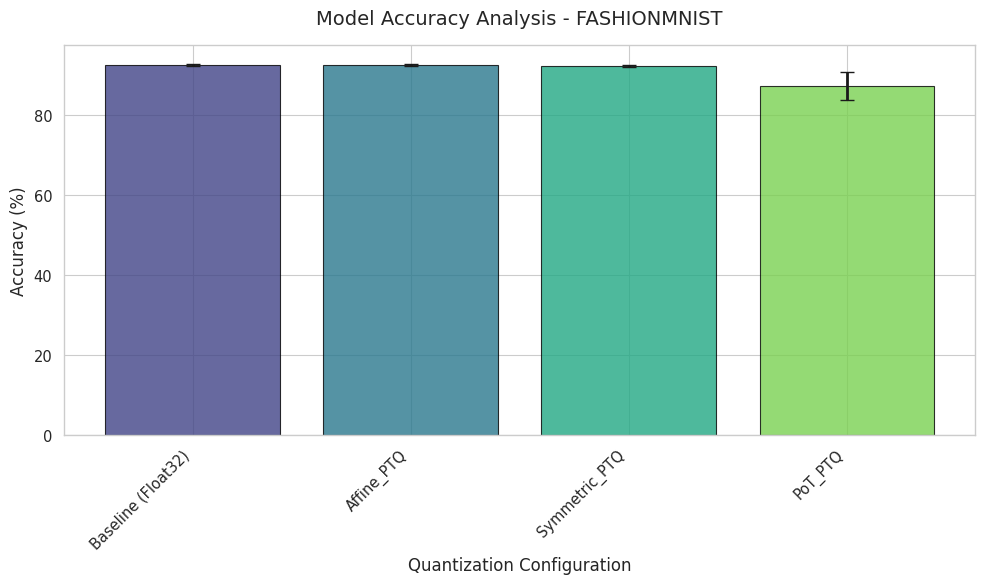

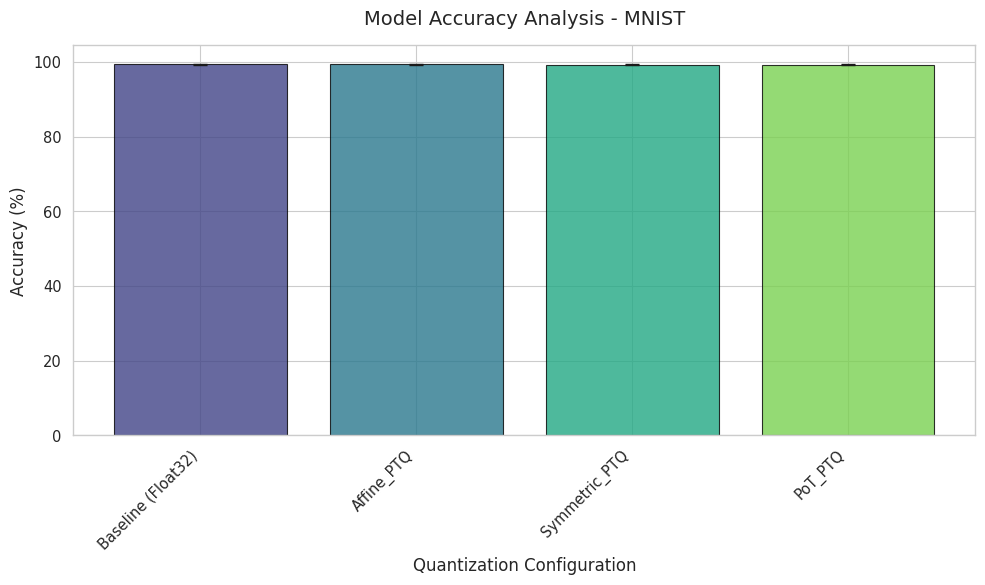

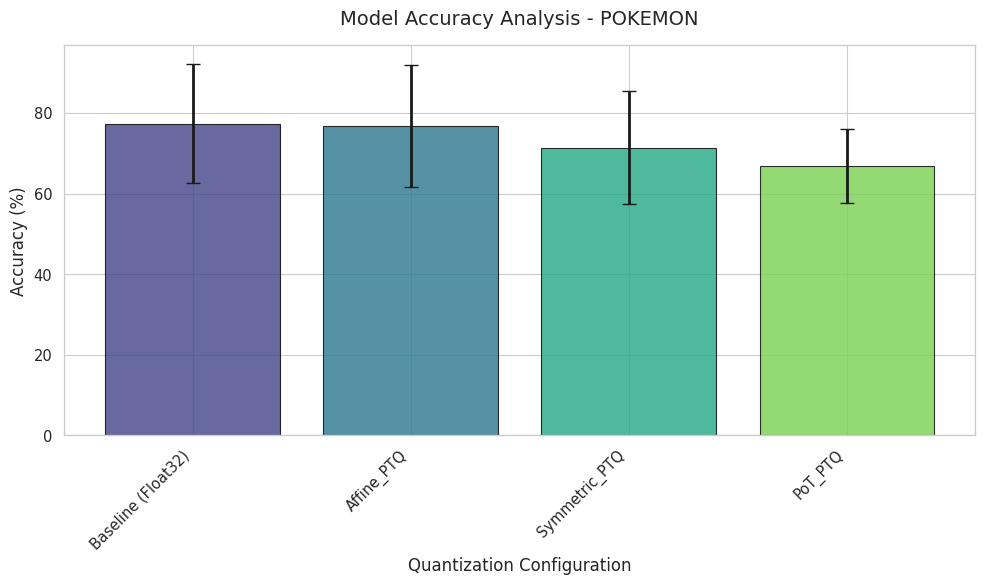

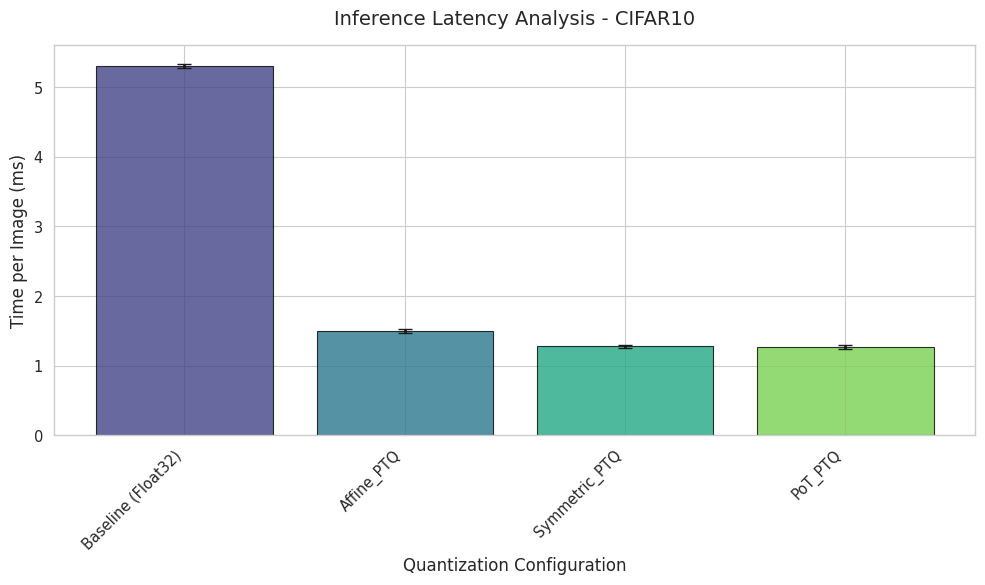

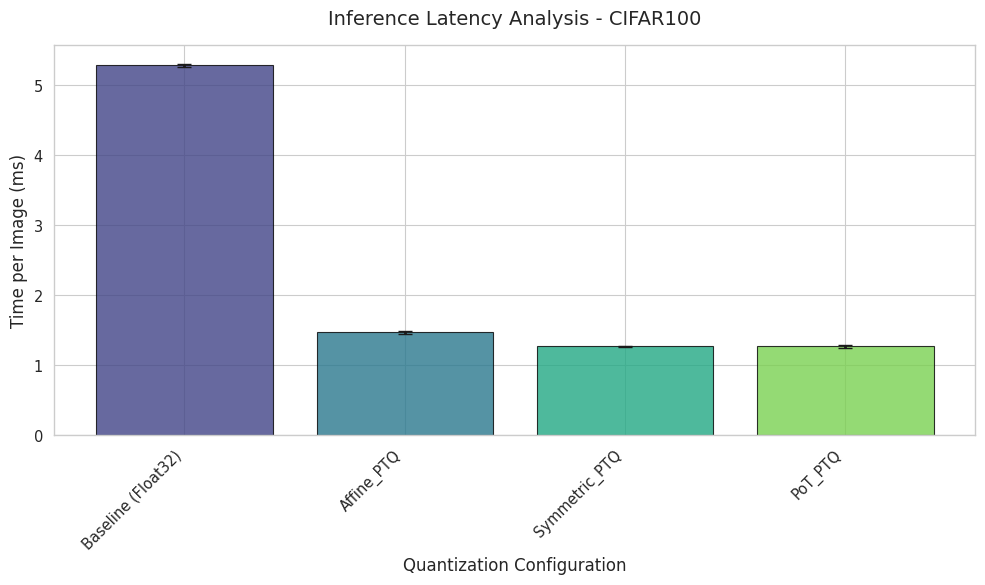

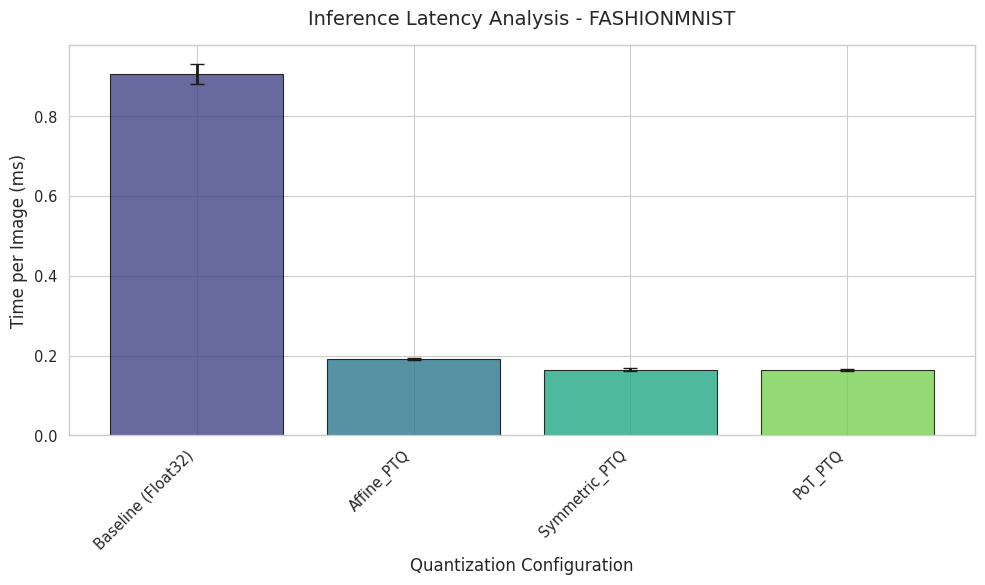

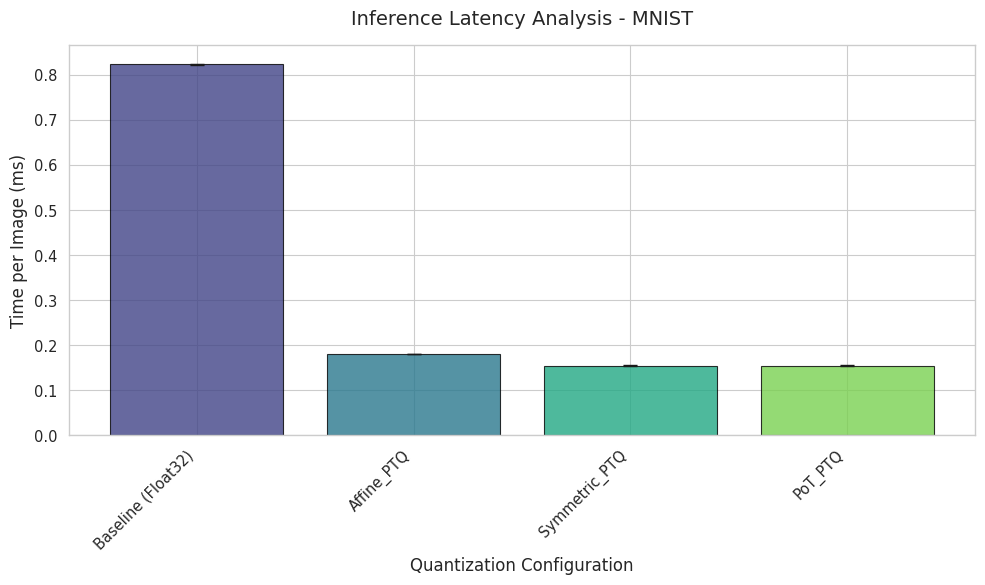

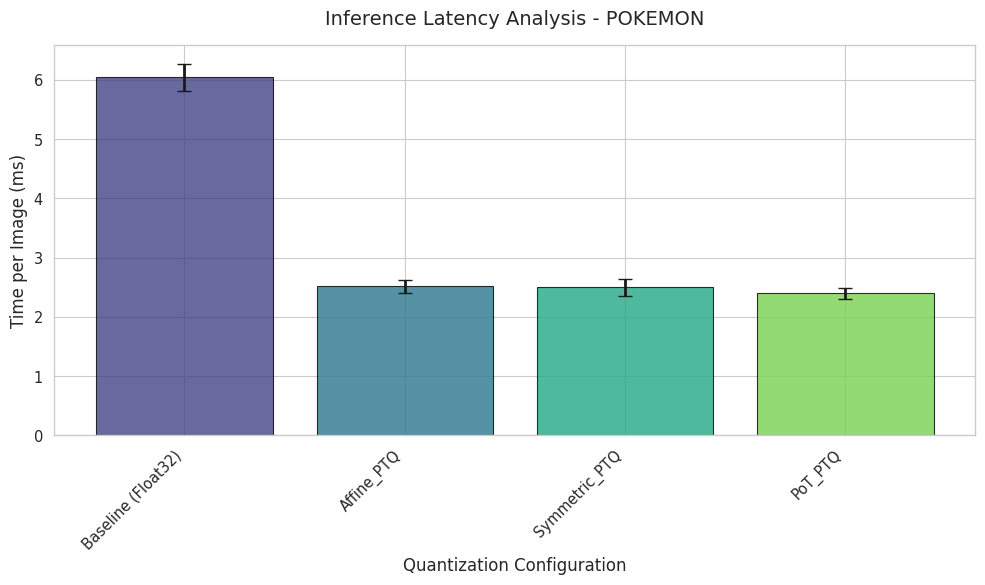

In [5]:
# Cell 3: Global Metrics Visualization
def plot_global_metric_with_errors(df, metric, std_metric, title, ylabel):
    datasets = df["dataset"].unique()
    
    for dataset in datasets:
        df_subset = df[df["dataset"] == dataset]
        
        plt.figure(figsize=(10, 6))
        
        # Plot bars with error bars
        bars = plt.bar(
            df_subset["config_name"], 
            df_subset[metric], 
            yerr=df_subset[std_metric], 
            capsize=5,
            color=sns.color_palette("viridis", len(df_subset)),
            alpha=0.8,
            edgecolor="black"
        )
        
        plt.title(f"{title} - {dataset}", pad=15)
        plt.ylabel(ylabel)
        plt.xlabel("Quantization Configuration")
        plt.xticks(rotation=45, ha="right")
        
        plt.tight_layout()
        plt.show()

# Plot Accuracy
plot_global_metric_with_errors(
    df_global, 
    metric="accuracy", 
    std_metric="accuracy_std", 
    title="Model Accuracy Analysis", 
    ylabel="Accuracy (%)"
)

# Plot Inference Time
plot_global_metric_with_errors(
    df_global, 
    metric="inference_time_ms", 
    std_metric="inference_time_ms_std", 
    title="Inference Latency Analysis", 
    ylabel="Time per Image (ms)"
)

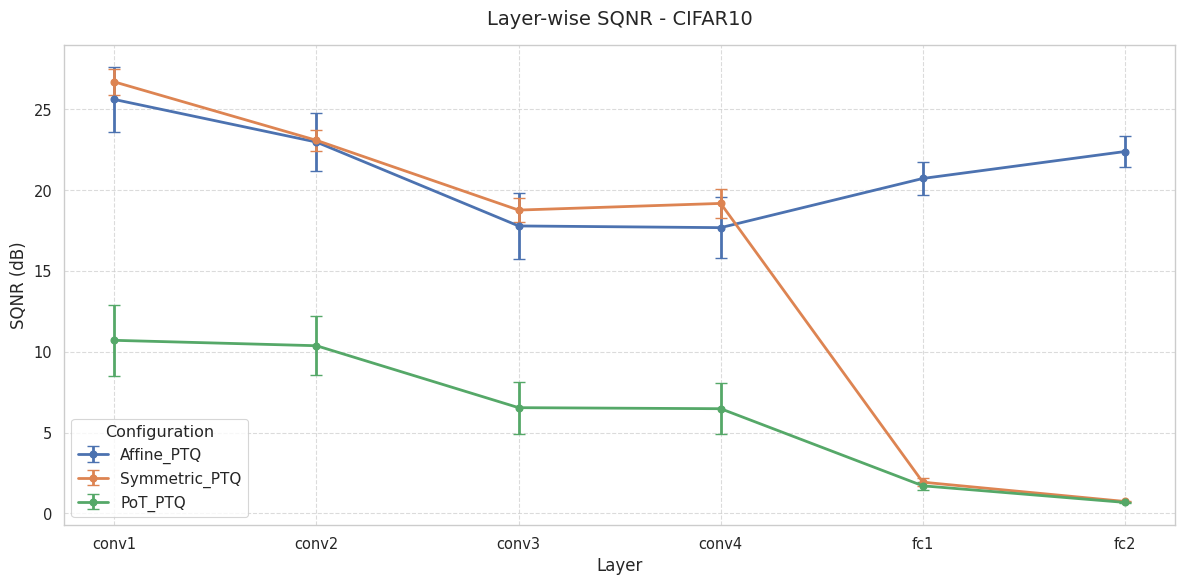

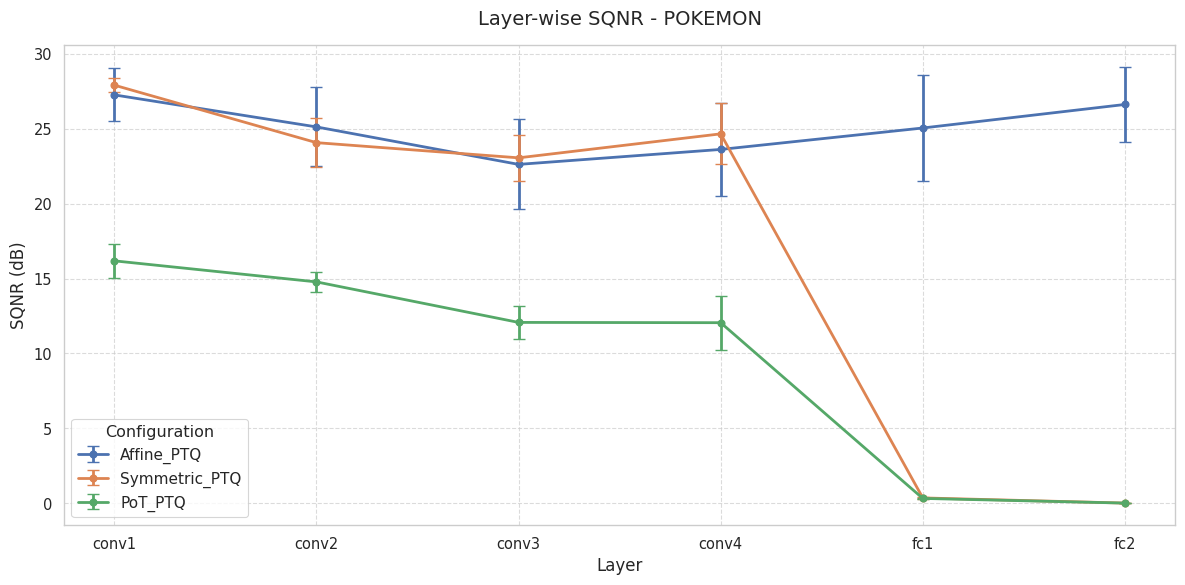

In [ ]:
# # Cell 4: Layer-wise Fidelity Visualization
# def plot_layer_fidelity(df, dataset_target):
#     df_subset = df[df["dataset"] == dataset_target]
    
#     if df_subset.empty:
#         return
        
#     plt.figure(figsize=(12, 6))
    
#     # Use seaborn lineplot for clean multi-line visualization
#     for config in df_subset["config_name"].unique():
#         df_config = df_subset[df_subset["config_name"] == config]
        
#         plt.errorbar(
#             df_config["layer_name"], 
#             df_config["sqnr_db"], 
#             yerr=df_config["sqnr_db_std"], 
#             marker="o", 
#             linestyle="-", 
#             linewidth=2,
#             capsize=4,
#             label=config
#         )
        
#     plt.title(f"Layer-wise SQNR - {dataset_target}", pad=15)
#     plt.ylabel("SQNR (dB)")
#     plt.xlabel("Layer")
#     plt.legend(title="Configuration")
#     plt.grid(True, linestyle="--", alpha=0.7)
    
#     plt.tight_layout()
#     plt.show()

# for dataset in DATASETS:
#     plot_layer_fidelity(df_layer, dataset)

In [8]:
# Plot layer-wise metrics dynamically
def plot_layer_fidelity(df, dataset_target, metric, std_metric, ylabel, title):
    df_subset = df[df["dataset"] == dataset_target]
    if df_subset.empty: 
        return
        
    plt.figure(figsize=(12, 6))
    
    for config in df_subset["config_name"].unique():
        df_config = df_subset[df_subset["config_name"] == config]
        
        # Pass dynamic metrics
        plt.errorbar(
            df_config["layer_name"], 
            df_config[metric], 
            yerr=df_config[std_metric], 
            marker="o", linestyle="-", linewidth=2, capsize=4, label=config
        )
        
    plt.title(f"{title} - {dataset_target}", pad=15)
    plt.ylabel(ylabel)
    plt.xlabel("Layer")
    plt.legend(title="Configuration")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

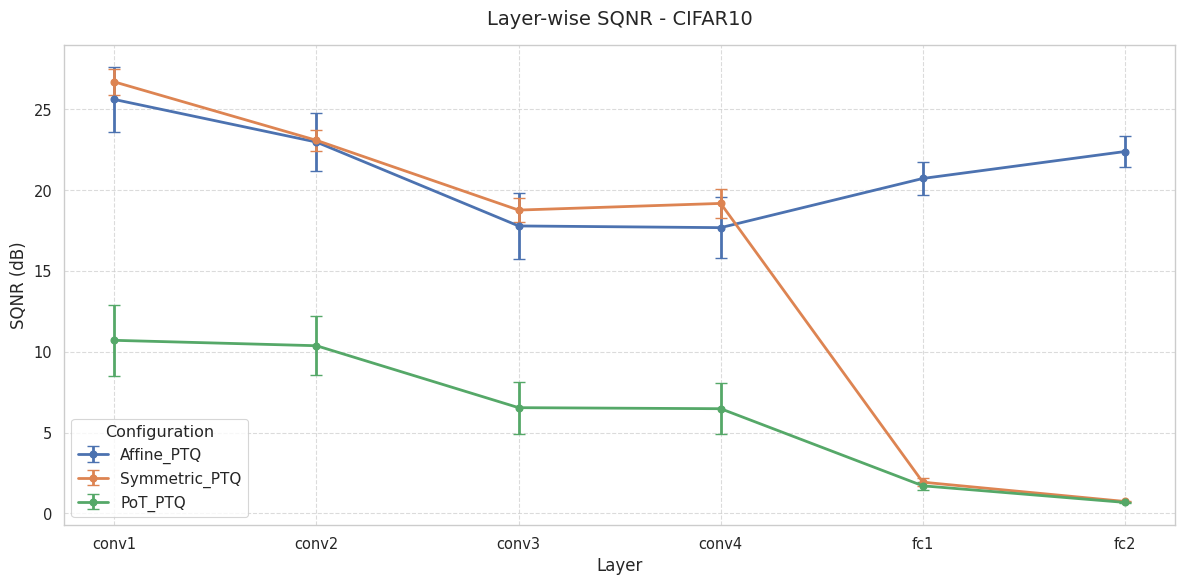

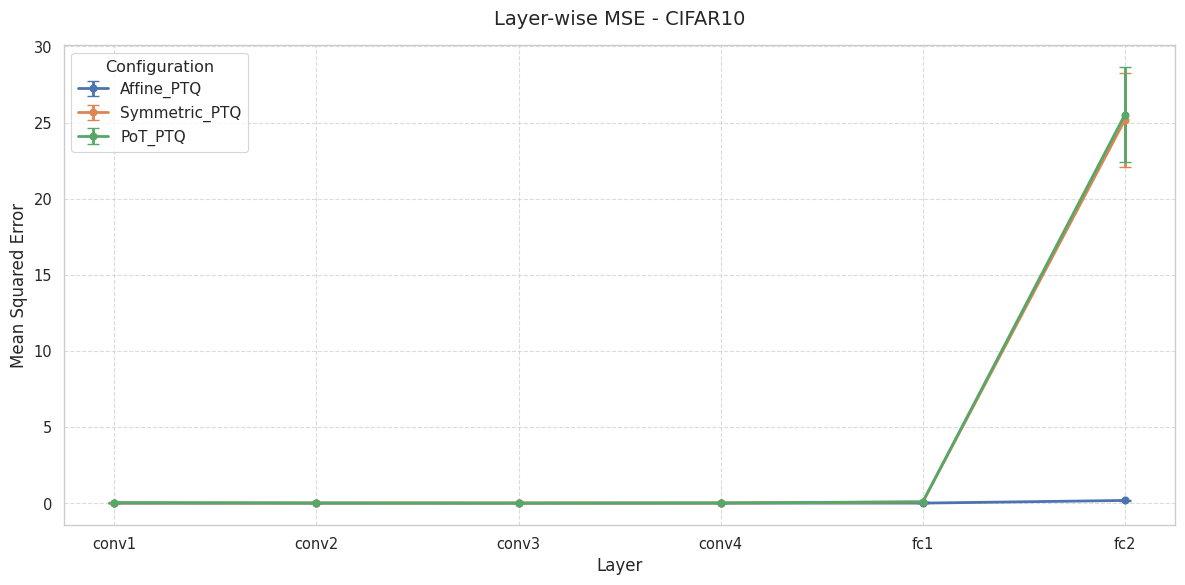

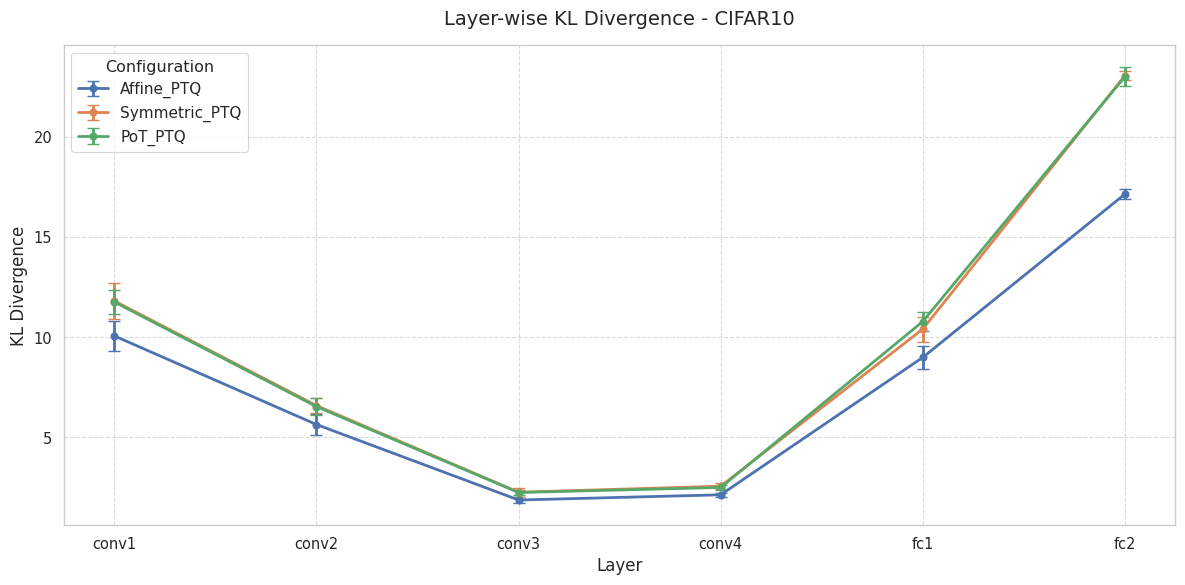

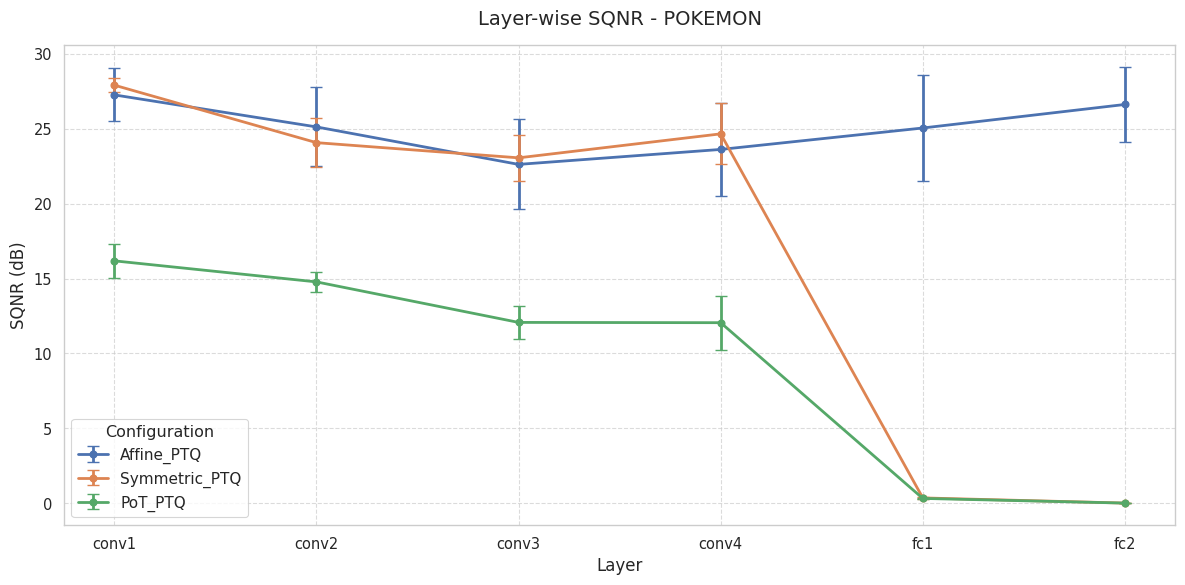

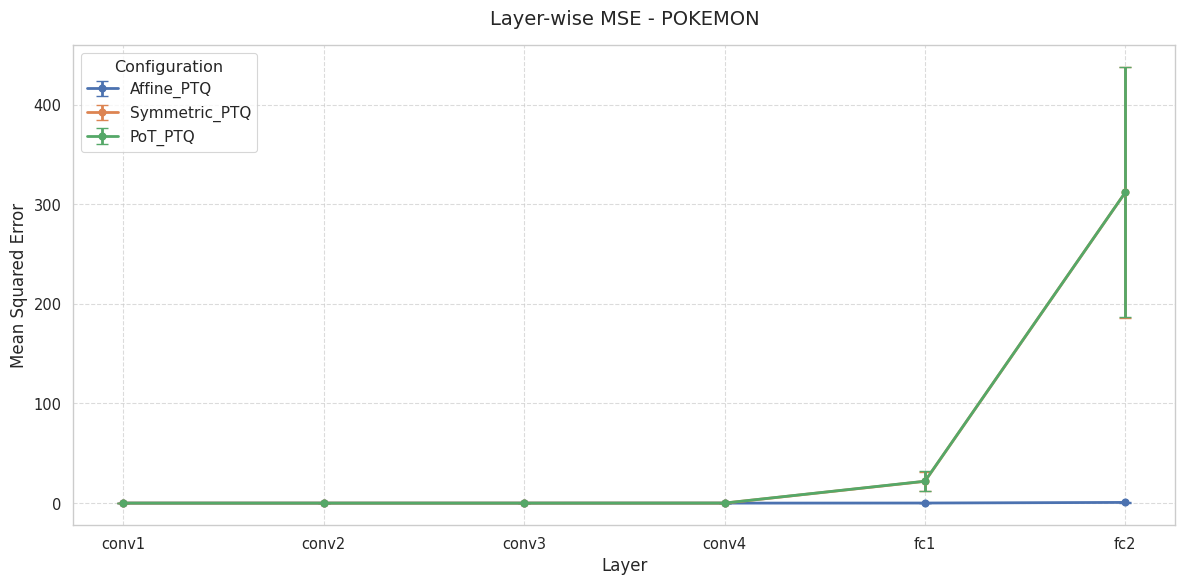

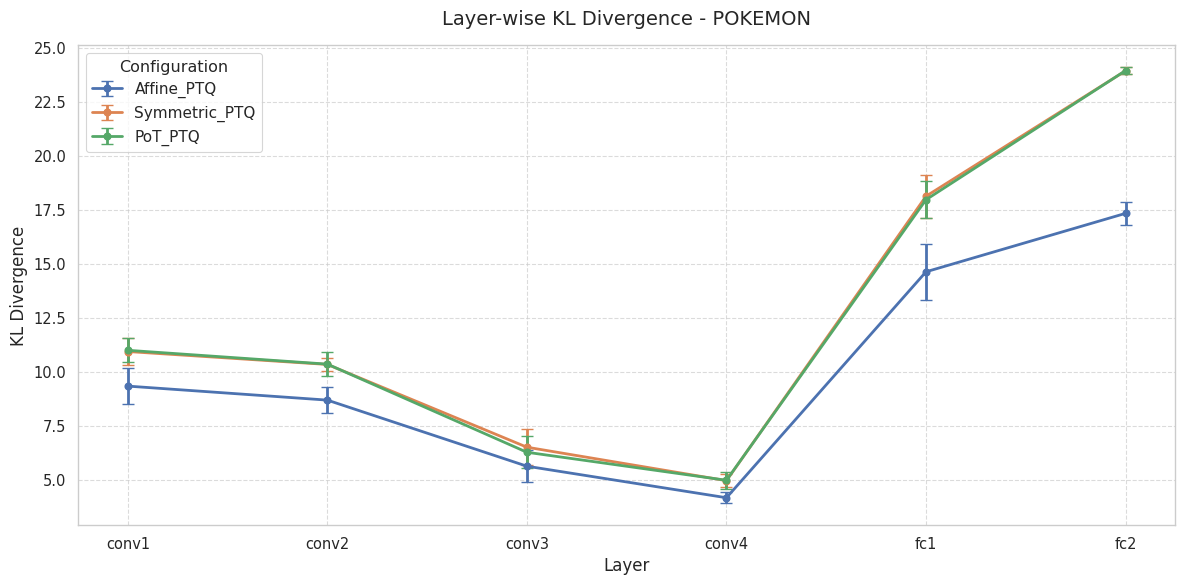

In [14]:
for dataset in DATASETS:
    plot_layer_fidelity(df_layer, dataset, "sqnr_db", "sqnr_db_std", "SQNR (dB)", "Layer-wise SQNR")
    plot_layer_fidelity(df_layer, dataset, "avg_mse", "avg_mse_std", "Mean Squared Error", "Layer-wise MSE")
    plot_layer_fidelity(df_layer, dataset, "kl_divergence", "kl_divergence_std", "KL Divergence", "Layer-wise KL Divergence")

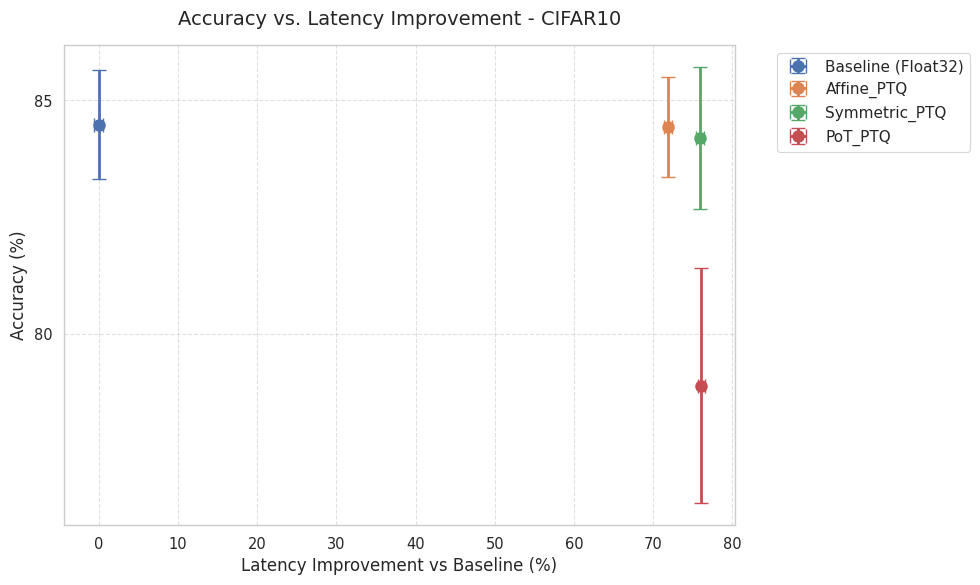

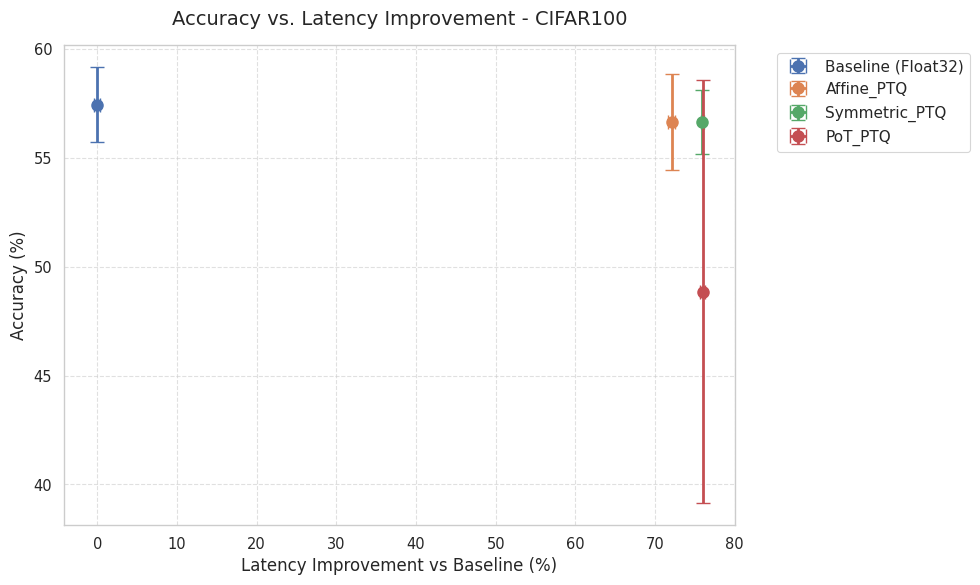

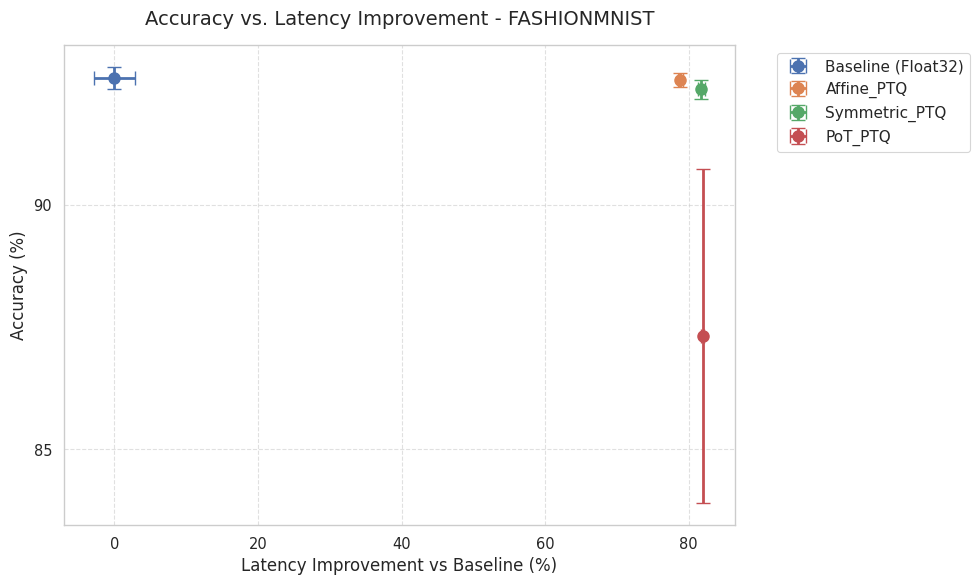

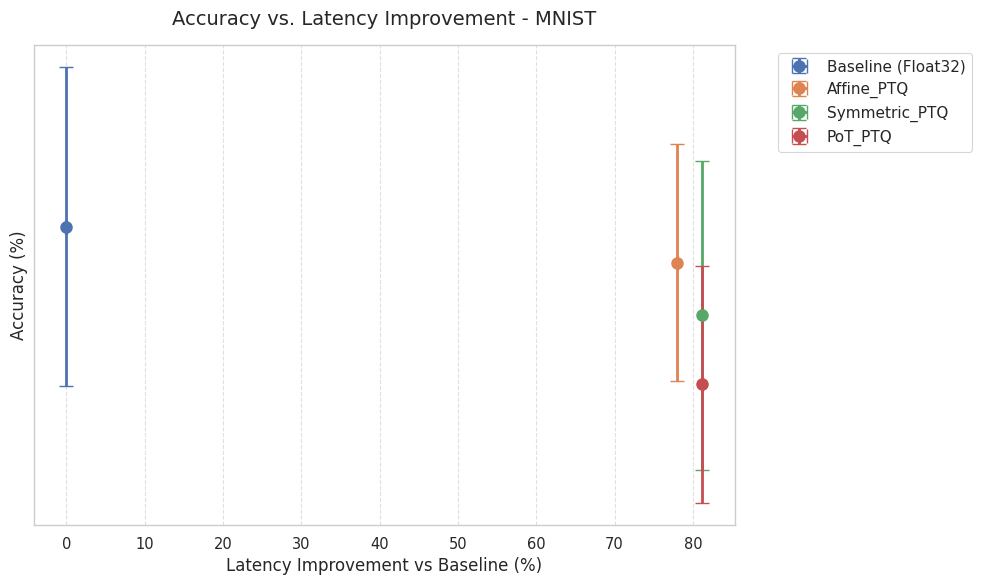

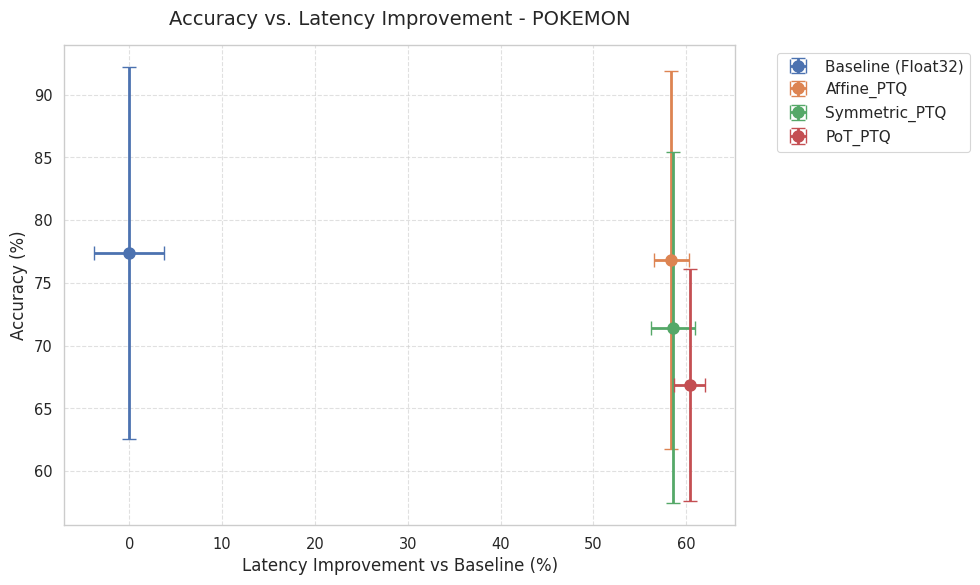

In [ ]:
# Cell: Accuracy vs. Latency Improvement Trade-off
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Trade-off visualization function
def plot_accuracy_latency_tradeoff(df):
    if df.empty:
        print("df_global is empty. Cannot plot tradeoff.")
        return
        
    for dataset in df["dataset"].unique():
        df_subset = df[df["dataset"] == dataset].copy()
        
        # Extract baseline inference time
        baseline_row = df_subset[df_subset["config_name"] == "Baseline (Float32)"]
        if baseline_row.empty:
            print(f"No Baseline found for {dataset}. Skipping tradeoff plot.")
            continue
            
        baseline_latency = baseline_row["inference_time_ms"].iloc[0]
        
        # Calculate percentage improvements and standard deviation scaling
        df_subset["latency_improvement"] = ((baseline_latency - df_subset["inference_time_ms"]) / baseline_latency) * 100
        df_subset["latency_improvement_std"] = (df_subset["inference_time_ms_std"] / baseline_latency) * 100
        
        plt.figure(figsize=(10, 6))
        
        # Plot configurations with 2D error bars
        for _, row in df_subset.iterrows():
            
            plt.errorbar(
                x=row["latency_improvement"], 
                y=row["accuracy"], 
                xerr=row["latency_improvement_std"], 
                yerr=row["accuracy_std"], 
                fmt="o", 
                markersize=8, 
                capsize=5, 
                label=row["config_name"]
            )
            
        # Draw vertical line for baseline (0% improvement)
        # plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Baseline Latency')
            
        plt.title(f"Accuracy vs. Latency Improvement - {dataset}", pad=15)
        plt.xlabel("Latency Improvement vs Baseline (%)")
        plt.ylabel("Accuracy (%)")
        
        # Place legend outside the plot
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

# Generate plot
plot_accuracy_latency_tradeoff(df_global)

In [ ]:
def register_activation_hooks(model, layer_names, storage_dict, is_quantized=False):
    """Sammelt Aktivierungen über Forward-Hooks."""
    hooks = []
    def hook_fn(name):
        def hook(module, inputs, output):
            # Dequantisierung für reale PTQ-Modelle
            if is_quantized and hasattr(output, 'dequantize'):
                storage_dict[name] = output.dequantize().detach().cpu().numpy().flatten()
            else:
                storage_dict[name] = output.detach().cpu().numpy().flatten()
        return hook

    for name, module in model.named_modules():
        if name in layer_names:
            hooks.append(module.register_forward_hook(hook_fn(name)))
    return hooks

def collect_activations(models_dict, sample_input, layer_names):
    """
    Sammelt Aktivierungen. 
    Nutzt Hooks für Baseline UND simulierte (FakeQuant) Modelle.
    """
    activations = {cfg: {} for cfg in models_dict.keys()}
    all_hooks = []
    
    def get_hook(cfg_name, l_name):
        def hook(m, i, o):
            # Falls das Modell vorbereitet (FakeQuant) ist, 
            # sind die Outputs noch Float-Tensoren mit Clipping-Effekt
            activations[cfg_name][l_name] = o.detach().cpu().numpy().flatten()
        return hook

    for cfg, model in models_dict.items():
        print(f"Registriere Hooks für: {cfg}")
        model.eval()
        
        # Wir registrieren Hooks für JEDES Modell im Dictionary, 
        # solange es kein JIT-ScriptModule ist.
        for name, module in model.named_modules():
            if name in layer_names:
                all_hooks.append(module.register_forward_hook(get_hook(cfg, name)))
    
    # Einmaliger Forward-Pass für alle Modelle
    with torch.no_grad():
        for cfg, model in models_dict.items():
            model(sample_input)
    
    # Hooks entfernen
    for h in all_hooks:
        h.remove()
        
    return activations

def plot_activation_distributions(activations_dict, layer_name):
    """Erstellt Histogramme und berechnet Statistiken."""
    plt.figure(figsize=(12, 6))
    colors = {"Baseline": "black", "Affine": "blue", "Symmetric": "green", "PoT": "red"}
    
    print(f"--- Statistiken für Layer: {layer_name} ---")
    for cfg, acts in activations_dict.items():
        if layer_name not in acts: continue
        data = acts[layer_name]
        
        print(f"[{cfg:9s}] Min: {np.min(data):.4f}, Max: {np.max(data):.4f}, "
              f"Mean: {np.mean(data):.4f}, Std: {np.std(data):.4f}")
        
        sns.histplot(data, bins=100, stat="density", element="step", fill=False, 
                     label=cfg, color=colors.get(cfg, "gray"), linewidth=2)

    plt.title(f"Aktivierungsverteilung: {layer_name}")
    plt.xlabel("Aktivierungswert")
    plt.ylabel("Dichte (Log-Skala)")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import copy
import torch
from src.fake_quantization.fake_quant_config import (
    get_fake_quant_affine_config,
    get_fake_quant_symmetric_config,
    get_fake_quant_pot_config
)
from src.torch_quantization.quantization_calibration import calibrate_model
from src.torch_quantization.quant_utils import fuse_layers
from src.utility.utils import get_data_loaders

# Vorbereitung der Daten
train_loader, _, _ = get_data_loaders()
sample_input = torch.randn(1, 3, 64, 64)
layers_to_analyze = ["conv1", "conv2", "conv3", "fc1", "fc2"]

current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    root_path = os.path.abspath(os.path.join(current_dir, '..'))
else:
    root_path = current_dir

# Pfade basierend auf dem korrekten Hauptverzeichnis definieren
MODEL_DIR = os.path.join(root_path, "results", "model")
QUANT_DIR = os.path.join(root_path, "results", "quantized_model")

# 2. Baseline Architektur initialisieren
num_classes = 10 # Aus deiner config.py
base_model = CNN(num_classes=num_classes)

# Gewichte in die Architektur laden
baseline_path = os.path.join(MODEL_DIR, "baseline_float32.pt")
base_model.load_state_dict(torch.load(baseline_path, map_location="cpu", weights_only=True))
base_model.eval()

# 1. Simuliertes Affine Modell
sim_model_aff = copy.deepcopy(base_model).to("cpu").eval()
sim_model_aff = fuse_layers(sim_model_aff)
sim_model_aff.qconfig = get_fake_quant_affine_config()
torch.ao.quantization.prepare(sim_model_aff, inplace=True)
calibrate_model(sim_model_aff, train_loader, num_batches=5, device="cpu")

# 2. Simuliertes Symmetric Modell
sim_model_sym = copy.deepcopy(base_model).to("cpu").eval()
sim_model_sym = fuse_layers(sim_model_sym)
sim_model_sym.qconfig = get_fake_quant_symmetric_config()
torch.ao.quantization.prepare(sim_model_sym, inplace=True)
calibrate_model(sim_model_sym, train_loader, num_batches=5, device="cpu")

# 3. Simuliertes PoT Modell
sim_model_pot = copy.deepcopy(base_model).to("cpu").eval()
sim_model_pot = fuse_layers(sim_model_pot)
sim_model_pot.qconfig = get_fake_quant_pot_config()
torch.ao.quantization.prepare(sim_model_pot, inplace=True)
calibrate_model(sim_model_pot, train_loader, num_batches=5, device="cpu")

# 4. Vergleichs-Dictionary erstellen
models_to_compare = {
    "Baseline": base_model,
    "Affine": sim_model_aff,
    "Symmetric": sim_model_sym,
    "PoT": sim_model_pot
}

# 5. Analyse für einen spezifischen Layer ausführen
# Nutzt die korrigierte collect_activations Funktion mit Hooks
acts = collect_activations(models_to_compare, sample_input, layers_to_analyze)

# Visualisierung für conv2
plot_activation_distributions(acts, "conv1")

In [27]:
def load_all_dataset_results():
    """
    Sucht und kombiniert alle quantization_results CSVs.
    Pfad: Von results/notebook -> hoch zu results -> in tests/
    """
    # 1. Pfad-Korrektur: Wir sind in 'results/notebook', wollen zu 'results/tests'
    current_dir = os.getcwd()
    
    # Wir gehen eine Ebene hoch (zu 'results')
    results_root = os.path.abspath(os.path.join(current_dir, '..'))
    # Dann in den 'tests' Ordner
    tests_dir = os.path.join(results_root, "results/tests")
    
    # 2. Suchmuster: Alle CSVs in den Unterordnern von 'tests'
    search_pattern = os.path.join(tests_dir, "*", "quantization_results_*.csv")
    files = glob.glob(search_pattern, recursive=True)
    
    if not files:
        raise FileNotFoundError(f"Keine CSV-Dateien gefunden. Pfad geprüft: {search_pattern}")
    
    all_data = []
    for f in files:
        df = pd.read_csv(f)
        # Extrahiert Dataset-Namen (z.B. CIFAR10) aus dem Ordnernamen
        dataset_name = os.path.basename(os.path.dirname(f))
        df['dataset'] = dataset_name
        all_data.append(df)
        print(f"Geladen: {f}")
    
    full_df = pd.concat(all_data, ignore_index=True)
    
    # 3. Normalisierung (Referenz: 'Baseline (Float32)')
    # Wir filtern nach Zeilen, die 'Baseline' im Namen haben
    baseline_df = full_df[full_df['config_name'].str.contains("Baseline")][['dataset', 'inference_time']]
    baseline_df = baseline_df.rename(columns={'inference_time': 'baseline_time'})
    
    full_df = full_df.merge(baseline_df, on='dataset')
    
    # Metriken berechnen
    full_df['normalized_latency'] = full_df['inference_time'] / full_df['baseline_time']
    full_df['latency_reduction_pct'] = (1 - full_df['normalized_latency']) * 100
    
    return full_df

# Daten laden
df_res = load_all_dataset_results()

Geladen: c:\Users\Dominic\Desktop\Forschungsprojekt\results/tests\CIFAR10\quantization_results_CIFAR10.csv
Geladen: c:\Users\Dominic\Desktop\Forschungsprojekt\results/tests\CIFAR100\quantization_results_CIFAR100.csv
Geladen: c:\Users\Dominic\Desktop\Forschungsprojekt\results/tests\FASHION_MNIST\quantization_results_FASHION_MNIST.csv
Geladen: c:\Users\Dominic\Desktop\Forschungsprojekt\results/tests\MNIST\quantization_results_MNIST.csv
Geladen: c:\Users\Dominic\Desktop\Forschungsprojekt\results/tests\POKEMON\quantization_results_POKEMON.csv


In [ ]:
from math import pi
def plot_latency_analysis(df):
    """Erstellt Barplots für absolute und relative Latency mit optimiertem Scaling."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Absolute Latency
    sns.barplot(ax=axes[0], data=df, x='dataset', y='inference_time', hue='config_name', palette="muted")
    axes[0].set_title("Absolute Inference Latency")
    axes[0].set_ylabel("Inference Time (s)")
    
    # 2. Relative Reduction
    df_quant = df[~df['config_name'].str.contains("Baseline")]
    sns.barplot(ax=axes[1], data=df_quant, x='dataset', y='latency_reduction_pct', hue='config_name', palette="magma")
    
    # --- Scaling Anpassungen ---
    # Setzt das Limit fest auf 0-100%, um die Relation zur Baseline (0% Reduktion) zu wahren
    axes[1].set_ylim(0, 80) 
    
    # Alternativ: Dynamisches Scaling mit Puffer für bessere Sichtbarkeit der Unterschiede
    # max_red = df_quant['latency_reduction_pct'].max()
    # axes[1].set_ylim(0, min(100, max_red + 10)) 

    axes[1].set_title("Latency Reduction (%) vs. Baseline")
    axes[1].set_ylabel("Reduktion in %")
    
    # Hilfslinien für bessere Lesbarkeit
    axes[1].yaxis.set_major_locator(plt.MultipleLocator(10)) # Alle 10% eine Linie
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    
def plot_pareto_efficiency(df):
    plt.figure(figsize=(10, 7))
    # Wir plotten die relative Latenz gegen die Accuracy
    sns.scatterplot(data=df, x='normalized_latency', y='accuracy', 
                    hue='config_name', style='dataset', s=200, alpha=0.8)
    
    # Vertikale Linie bei 1.0 (Baseline Speed)
    plt.axvline(1.0, color='red', linestyle='--', label='Baseline Latency')
    
    plt.title("Pareto-Efficiency: Accuracy vs. Normalized Latency")
    plt.xlabel("Normalisierte Latenz (niedriger = schneller)")
    plt.ylabel("Accuracy (%)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

def plot_radar_comparison(df, dataset_name):
    """
    Erstellt ein Radar-Chart für einen spezifischen Datensatz.
    Vergleicht Accuracy, F1, Latency Reduction und Model Compression.
    """
    # 1. Daten für das gewählte Dataset filtern
    df_ds = df[df['dataset'] == dataset_name].copy()
    if df_ds.empty:
        print(f"Keine Daten für Dataset '{dataset_name}' gefunden.")
        return

    # 2. Metriken definieren
    # Wir nutzen 'bits', da 8-bit vs 32-bit ein schöner Kontrast im Radar ist
    metrics = ['accuracy', 'f1_score', 'latency_reduction_pct', 'bits']
    labels = ['Accuracy (%)', 'F1 Score', 'Latency Red. (%)', 'Bit-Width (Inv)']
    
    # Daten für Radar-Skalierung vorbereiten
    # Bit-Width invertieren (32 bit -> klein, 8 bit -> groß), damit 'mehr' immer 'besser' ist
    df_ds['bits_inv'] = 32 - df_ds['bits'] 
    plot_metrics = ['accuracy', 'f1_score', 'latency_reduction_pct', 'bits_inv']

    N = len(plot_metrics)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Farben für deine Strategien
    colors = {"Baseline (Float32)": "black", "Affine_PTQ": "blue", 
              "Symmetric_PTQ": "green", "PoT_PTQ": "red"}

    for i, row in df_ds.iterrows():
        values = []
        for m in plot_metrics:
            val = row[m]
            # Normalisierung auf [0, 1] für die Darstellung
            if m == 'accuracy' or m == 'latency_reduction_pct':
                values.append(val / 100.0)
            elif m == 'f1_score':
                values.append(val)
            elif m == 'bits_inv':
                values.append(val / 24.0) # (32-8)/24 = 1.0
        
        values += values[:1]
        name = row['config_name']
        ax.plot(angles, values, linewidth=2, label=name, color=colors.get(name, "gray"))
        ax.fill(angles, values, alpha=0.1, color=colors.get(name, "gray"))

    plt.xticks(angles[:-1], labels)
    ax.set_ylim(0, 1.1)
    plt.title(f"Multi-Metric Trade-off: {dataset_name}\n(Normalized: Outward is Better)", pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()
    
def plot_layer_error_distribution(root_path):
# Lädt die Fidelity-Daten (MSE/SQNR) pro Layer
# Pfad: results/tests/CIFAR10/fidelity_*.csv
    path = os.path.join(root_path, "results", "tests", "CIFAR10", "fidelity_*.csv")
    files = glob.glob(path)

    layer_data = []
    for f in files:
        tmp = pd.read_csv(f)
        tmp['method'] = os.path.basename(f).split('_')[1]
        layer_data.append(tmp)

    df_layer = pd.concat(layer_data)

    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df_layer, x='layer_name', y='sqnr_db', hue='method', split=True)
    plt.title("SQNR Distribution per Layer (Higher is Better Fidelity)")
    plt.ylabel("SQNR (dB)")
    plt.xticks(rotation=45)
    plt.show()
# Plots anzeigen
plot_latency_analysis(df_res)
plot_pareto_efficiency(df_res)
# plot_radar_comparison(df_res, "CIFAR10")
# plot_layer_error_distribution("CIFAR10")

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_comparative_fidelity(dataset_name="POKEMON"):
    # 1. Path Setup (results/notebook -> results/tests)
    current_dir = os.getcwd()
    results_root = os.path.abspath(os.path.join(current_dir, '..'))
    folder_path = os.path.join(results_root, "results/tests", dataset_name)
    
    # 2. Load all PTQ fidelity files
    search_pattern = os.path.join(folder_path, "fidelity_*_PTQ.csv")
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"No files found at: {search_pattern}")
        return

    all_methods = []
    for f in files:
        df = pd.read_csv(f)
        # Extract method name (e.g., Affine, Symmetric, PoT)
        method = os.path.basename(f).split('_')[1]
        df['method'] = method
        all_methods.append(df)
    
    df_comp = pd.concat(all_methods, ignore_index=True)

    # 3. Visualization: SQNR Comparison (Higher is better)
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df_comp, x='layer_name', y='sqnr_db', hue='method', 
                 marker='o', markersize=10, linewidth=3)
    
    plt.yscale('linear')
    plt.title(f'Signal-to-Quantization-Noise Ratio (SQNR) per Layer: {dataset_name}', fontsize=16)
    plt.ylabel('SQNR (dB) - Signal Quality', fontsize=12)
    plt.xlabel('Neural Network Layer', fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(title="Strategy", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adding a threshold line for "Poor Quality" (Scientific Reference)
    plt.axhline(y=10, color='r', linestyle='--', alpha=0.5, label='Low Quality Threshold')
    
    plt.tight_layout()
    plt.show()

# Run the comparison
plot_comparative_fidelity("POKEMON")

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_comparative_mse(dataset_name="POKEMON"):
    # 1. Setup paths from results/notebook to results/tests
    current_dir = os.getcwd()
    results_root = os.path.abspath(os.path.join(current_dir, '..'))
    folder_path = os.path.join(results_root, "results/tests", dataset_name)
    
    # 2. Collect all fidelity files
    files = glob.glob(os.path.join(folder_path, "fidelity_*_PTQ.csv"))
    all_data = []
    
    for f in files:
        df = pd.read_csv(f)
        method = os.path.basename(f).split('_')[1]
        df['method'] = method
        all_data.append(df)
    
    df_all = pd.concat(all_data, ignore_index=True)

    # 3. Create the MSE Plot
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_all, x='layer_name', y='avg_mse', hue='method', 
                 marker='s', markersize=8, linewidth=2.5)
    
    # Use Log Scale because of the range from 0.00006 to 25.0
    plt.yscale('log') 
    plt.title(f'Mean Squared Error (MSE) per Layer: {dataset_name}', fontsize=15)
    plt.ylabel('Average MSE (Log Scale)', fontsize=12)
    plt.xlabel('Layer Name', fontsize=12)
    # plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(title="Quantization Strategy")
    plt.tight_layout()
    plt.show()

plot_comparative_mse("POKEMON")

In [ ]:
def plot_comparative_kl(dataset_name="POKEMON"):
    # (Reuse the loading logic from the MSE function above)
    current_dir = os.getcwd()
    results_root = os.path.abspath(os.path.join(current_dir, '..'))
    folder_path = os.path.join(results_root, "results/tests", dataset_name)
    files = glob.glob(os.path.join(folder_path, "fidelity_*_PTQ.csv"))
    df_all = pd.concat([pd.read_csv(f).assign(method=os.path.basename(f).split('_')[1]) for f in files])

    plt.figure(figsize=(12, 6))
    # Bar plot is often better for KL to show absolute "Information Distance"
    sns.barplot(data=df_all, x='layer_name', y='kl_divergence', hue='method', palette="viridis")
    
    plt.title(f'KL-Divergence (Information Loss) per Layer: {dataset_name}', fontsize=15)
    plt.ylabel('KL Divergence', fontsize=12)
    plt.xlabel('Layer Name', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.legend(title="Strategy")
    plt.tight_layout()
    plt.show()

plot_comparative_kl("POKEMON")

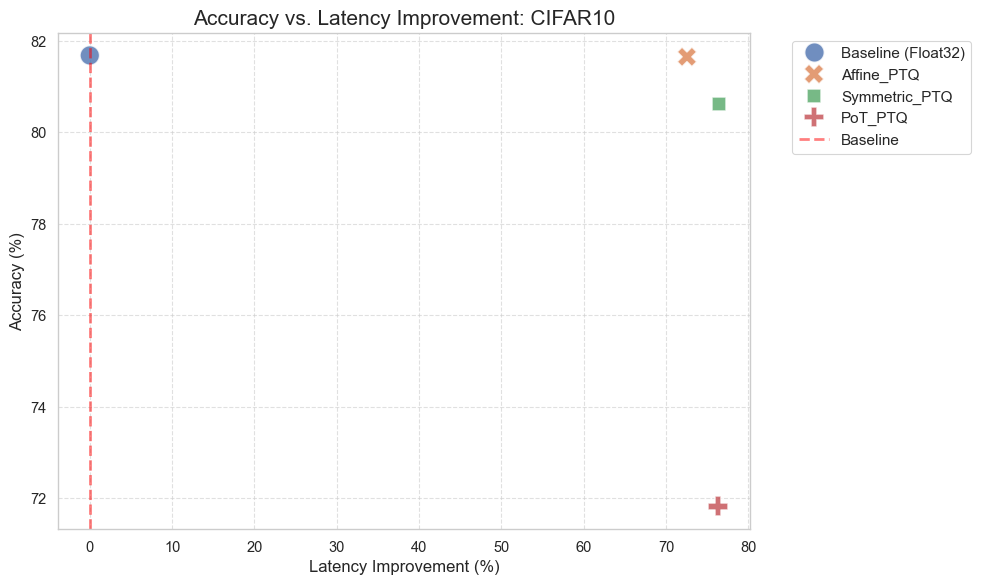

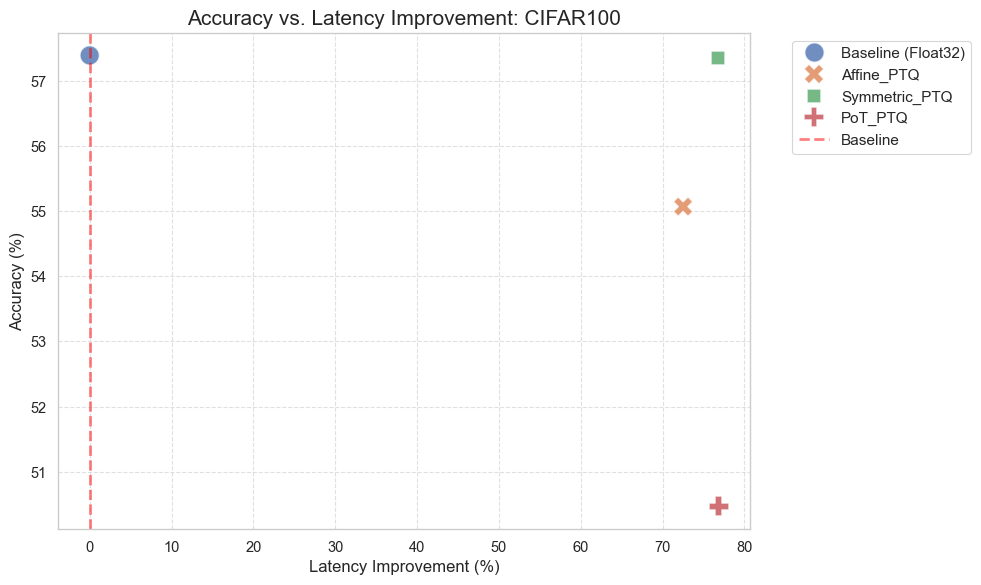

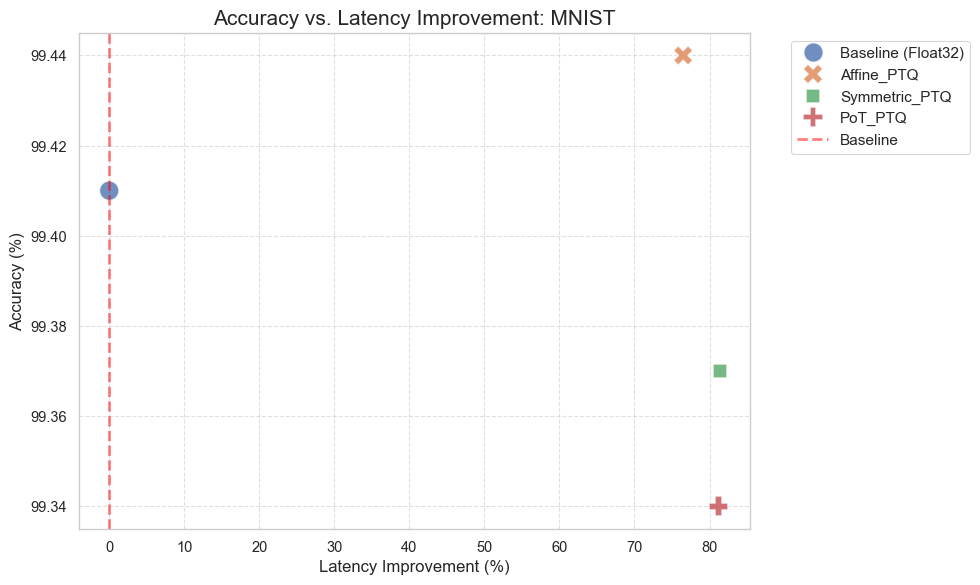

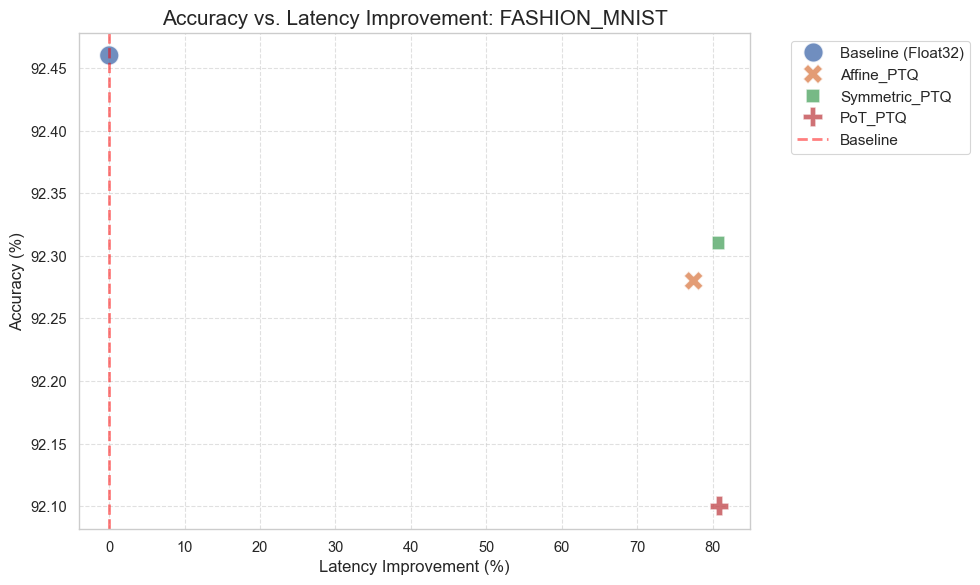

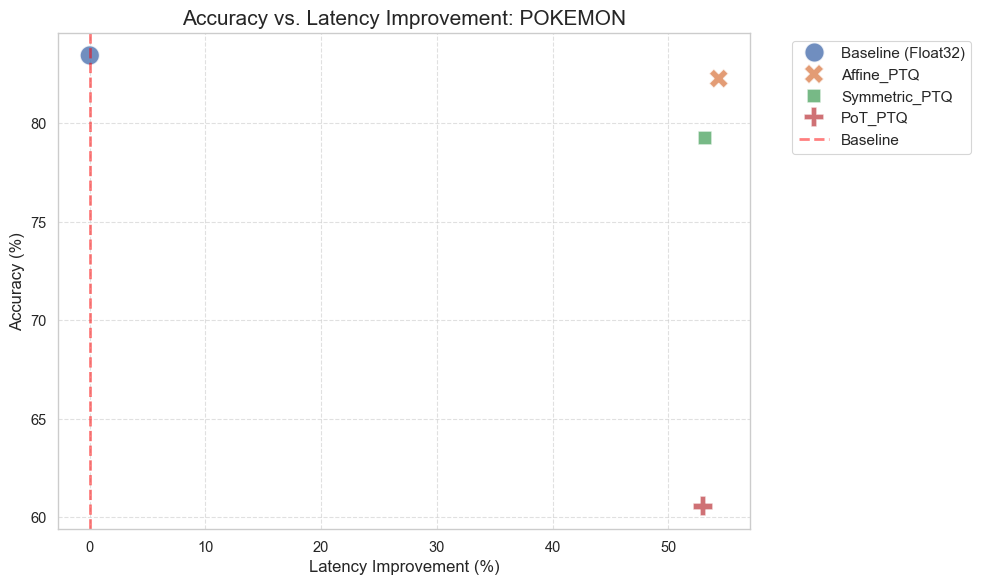

In [32]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

def save_individual_tradeoff_plots(df, output_dir="results/plots"):
    # Create directory if missing
    os.makedirs(output_dir, exist_ok=True)
    
    plot_df = df.copy()
    plot_df['latency_reduction_pct'] = plot_df['latency_reduction_pct'].fillna(0)
    
    target_datasets = ['CIFAR10', 'CIFAR100', 'MNIST', 'FASHION_MNIST', 'POKEMON']
    
    # Loop through each target dataset
    for dataset in target_datasets:
        # Filter data for current iteration
        df_subset = plot_df[plot_df['dataset'] == dataset]
        
        # Skip iteration if no data exists
        if df_subset.empty:
            continue
            
        plt.figure(figsize=(10, 6))
        
        # Create standard scatterplot
        sns.scatterplot(
            data=df_subset, 
            x='latency_reduction_pct', 
            y='accuracy', 
            hue='config_name', 
            style='config_name', 
            s=200, 
            alpha=0.8,
            palette="deep"
        )
        
        plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Baseline')
        
        plt.title(f"Accuracy vs. Latency Improvement: {dataset}", fontsize=15)
        plt.xlabel("Latency Improvement (%)", fontsize=12)
        plt.ylabel("Accuracy (%)", fontsize=12)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Prevent legend cutoff
        plt.tight_layout()
        
        # Save figure before show()
        file_path = os.path.join(output_dir, f"tradeoff_{dataset}.png")
        plt.savefig(file_path, bbox_inches='tight', dpi=300)
        
        plt.show()
        
        # Close figure to free memory
        plt.close()

# Execute function
save_individual_tradeoff_plots(df_res)